<a href="https://colab.research.google.com/github/SergioArtur/challenge-datascience1/blob/main/ChallengeDS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [1]:
# ! indica que iremos usar um prompt de comando na máquina.
# Iremos usar uma versão específica devido a estabilidade dessa versão.
!pip install matplotlib==3.6.2
!pip install numpy==1.23.5

In [2]:
# Importando as bibliotecas padrão de visualização de dados "matplotlib"
import matplotlib #Importação sem apelido (alias)
# Importado a biblioteca "numpy" para trabalhar com arrays (listas) multidimensionais e funções matemáticas.
import numpy as np #Importação utilizado um apelido np (famosos alias).
#matplotlib.pyplot" é um módulo da biblioteca matplotlib em Python, que é amplamente utilizado para criar gráficos e visualizações de dados.
'''Ele é um submódulo no Matplotlib, ou seja, um módulo dentro do módulo, responsável por trabalhar também com a visualização de dados, como gráficos de linha,
barras, pizza, histogramas e dispersão, além de permitir personalização e criação de animações'''
import matplotlib.pyplot as plt #Importação utilizado um apelido plt (famosos alias).
#Visualizando as versões instaladas.
print(matplotlib.__version__) #Dunder methods: métodos mágicos ou dunder methods são parâmetros com dois underlines seguidos: __.
plt.show() #Verificar se o plt está apresentando sem erros.
np.__version__

3.6.2


'1.23.5'

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


Generating locales (this might take a while)...
  pt_BR.UTF-8... done
Generation complete.

Faturamento da 1ª Loja: R$ 1.534.509,12
Faturamento da 2ª Loja: R$ 1.488.459,06
Faturamento da 3ª Loja: R$ 1.464.025,03
Faturamento da 4ª Loja: R$ 1.384.497,58

Faturamento Total das Lojas: R$ 5.871.490,79



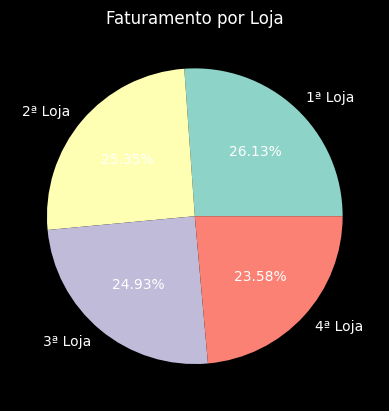

In [17]:
!sudo locale-gen pt_BR.UTF-8
!sudo update-locale
#!locale -a
import locale

#Altera a configuração regional (locale) do seu ambiente Python para Português do Brasil (pt_BR).
locale.setlocale(locale.LC_ALL, 'pt_BR.utf8')

# Formatar como moeda brasileira
#Formata o número 98765432.10 como uma moeda, segundo o padrão da localidade definida anteriormente (pt_BR.utf8).
# "grouping=True" diz ao Python para usar o separador de milhar (ponto, no caso brasileiro).
locale.currency(98765432.10, grouping=True)# Saída: 'R$ 1.2345678,90'

#Criando uma lista com o nome das lojas.
Lojas = ['1ª Loja','2ª Loja','3ª Loja','4ª Loja']
#Realizando a soma do faturamento de cada loja.
faturamento1 = loja["Preço"].sum()
faturamento2 = loja2["Preço"].sum()
faturamento3 = loja3["Preço"].sum()
faturamento4 = loja4["Preço"].sum()
#Somando o faturamento total das lojas.
faturamentoT = loja["Preço"].sum() + loja2["Preço"].sum() + loja3["Preço"].sum() + loja4["Preço"].sum()

#Mostra o faturamento de cada loja com a formatação da moeda brasileira.
print(f'\nFaturamento da 1ª Loja: {locale.currency(faturamento1, grouping=True)}')
print(f'Faturamento da 2ª Loja: {locale.currency(faturamento2, grouping=True)}')
print(f'Faturamento da 3ª Loja: {locale.currency(faturamento3, grouping=True)}')
print(f'Faturamento da 4ª Loja: {locale.currency(faturamento4, grouping=True)}\n')
print(f'Faturamento Total das Lojas: {locale.currency(faturamentoT, grouping=True)}\n')

#Mostra o gráfica de pizza em porcentagem para uma melhor visualização.
plt.pie(x=[faturamento1, faturamento2, faturamento3, faturamento4], labels=Lojas, autopct='%1.2f%%')
'''
autopct='%1.2f%%'
Esse parâmetro exibe automaticamente a porcentagem que cada fatia representa.
O formato '%1.2f%%' significa:
 % → início da formatação
 1.2f → número formatado com 1 dígito mínimo antes da vírgula e 2 casas decimais
 %% → escapa o símbolo % para que ele apareça no texto
Exemplo de saída: 25.00%
'''
plt.title('Faturamento por Loja')
plt.show()

# 2. Vendas por Categoria



 Quantidade Total de produtos vendidos por Categoria do Produto
brinquedos               1290
eletrodomesticos         1149
eletronicos              1772
esporte e lazer          1113
instrumentos musicais     753
livros                    742
moveis                   1886
utilidades domesticas     730
Name: count, dtype: int64



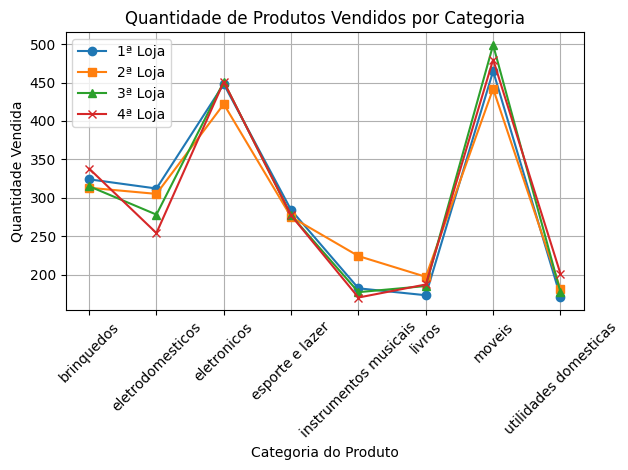

In [5]:
#Quantidade de produtos vendidos por categoria.
vc_L1 = loja['Categoria do Produto'].value_counts()
vc_L2 = loja2['Categoria do Produto'].value_counts()
vc_L3 = loja3['Categoria do Produto'].value_counts()
vc_L4 = loja4['Categoria do Produto'].value_counts()

tvc = vc_L1 + vc_L2 + vc_L3 + vc_L4
print(f'\n Quantidade Total de produtos vendidos por {tvc}\n')


# Obtem todas as categorias únicas entre as lojas
todas_categorias = sorted(set(vc_L1.index) | set(vc_L2.index) | set(vc_L3.index) | set(vc_L4.index))

# Reindexar para alinhar todas as categorias (preenche faltantes com 0)
vc_L1 = vc_L1.reindex(todas_categorias, fill_value=0)
vc_L2 = vc_L2.reindex(todas_categorias, fill_value=0)
vc_L3 = vc_L3.reindex(todas_categorias, fill_value=0)
vc_L4 = vc_L4.reindex(todas_categorias, fill_value=0)

# Plotando com categorias no eixo X
plt.plot(todas_categorias, vc_L1.values, marker='o', label='1ª Loja')
plt.plot(todas_categorias, vc_L2.values, marker='s', label='2ª Loja')
plt.plot(todas_categorias, vc_L3.values, marker='^', label='3ª Loja')
plt.plot(todas_categorias, vc_L4.values, marker='x', label='4ª Loja')

#Rótulo do gráfico
plt.title('Quantidade de Produtos Vendidos por Categoria')
plt.xlabel('Categoria do Produto')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# 3. Média de Avaliação das Lojas

Média de avaliação da 1ª Loja: 3.98
Média de avaliação da 2ª loja: 4.04
Média de avaliação da 3ª loja: 4.05
Média de avaliação da 4ª loja: 4.0



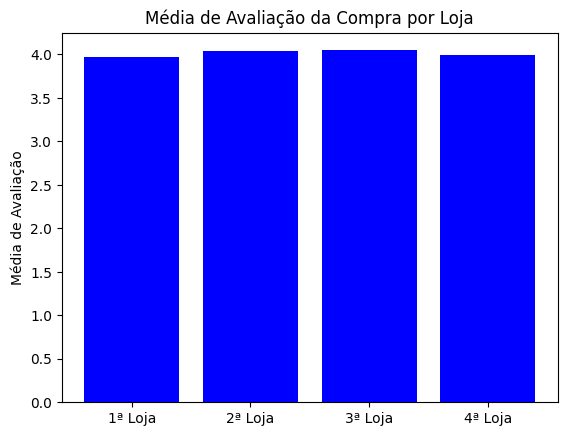

In [6]:
#Criando uma lista com as médias das lojas com o método mean() para obter a média dos dados, advindo da biblioteca do pandas.
mediasL = [
    loja["Avaliação da compra"].mean(),
    loja2["Avaliação da compra"].mean(),
    loja3["Avaliação da compra"].mean(),
    loja4["Avaliação da compra"].mean()]
#Configurado para mostrar duas casa decimais após a vírgula e depois retirado a média de todas as avaliações da loja.
print(f'Média de avaliação da 1ª Loja: {round(loja["Avaliação da compra"].mean(), 2)}')
print(f'Média de avaliação da 2ª loja: {round(loja2["Avaliação da compra"].mean(),2)}')
print(f'Média de avaliação da 3ª loja: {round(loja3["Avaliação da compra"].mean(),2)}')
print(f'Média de avaliação da 4ª loja: {round(loja4["Avaliação da compra"].mean(),2)}\n')
#Mostrando o gráfico de barras com plt.
plt.bar(x=Lojas, height=mediasL, color='blue') # Gráfico de barras e azul
plt.ylabel('Média de Avaliação') # Mostrar título do eixo Y.
plt.title('Média de Avaliação da Compra por Loja') # Mostrar título do eixo X.
#plt.ylim(0, 5)  # Se a escala for de 0 a 5, por exemplo
plt.show()

# 4. Produtos Mais e Menos Vendidos

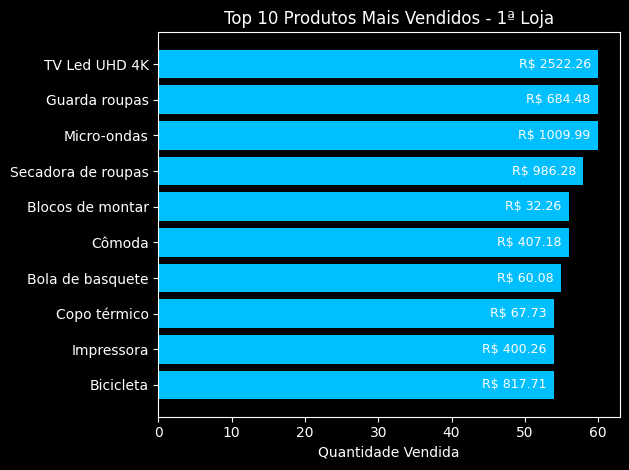

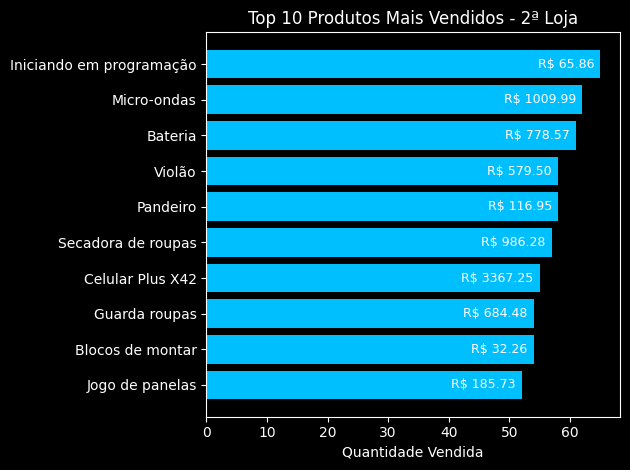

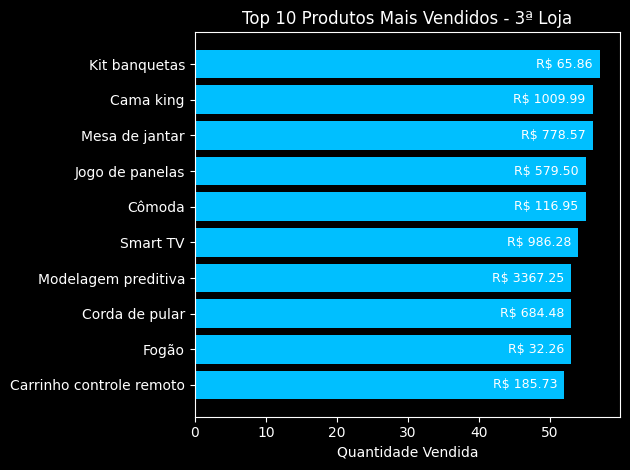

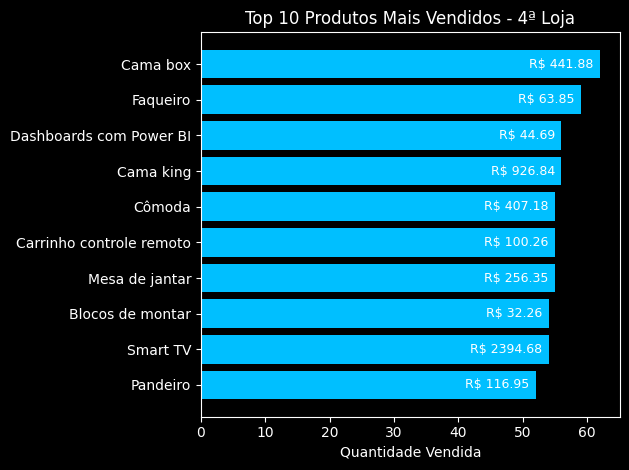

In [7]:
'''
print(f'\nMais vendido na 1ª loja\n', loja[['Produto', 'Preço']].value_counts().head(10), '\n') # Listando os produtos, realizando a contagem e obtendo os 10 mais vendidos.
print(f'\nMais vendido na 2ª loja\n', loja2[['Produto', 'Preço']].value_counts().head(10), '\n')
print(f'\nMais vendido na 3ª loja\n', loja3[['Produto', 'Preço']].value_counts().head(10), '\n')
print(f'\nMais vendido na 4ª loja\n', loja4[['Produto', 'Preço']].value_counts().head(10), '\n')
'''

# Top 10 produtos mais vendidos (por nome)
mais_vendidos_L1 = loja['Produto'].value_counts().head(10)
mais_vendidos_L2 = loja2['Produto'].value_counts().head(10)
mais_vendidos_L3 = loja3['Produto'].value_counts().head(10)
mais_vendidos_L4 = loja4['Produto'].value_counts().head(10)

# Agora pegamos os preços únicos desses produtos
# Remove duplicados com base no produto (mantendo o primeiro preço)
# Remove duplicados com base no produto, de todas as lojas
df1 = loja.drop_duplicates(subset='Produto')[['Produto', 'Preço']]
df2 = loja2.drop_duplicates(subset='Produto')[['Produto', 'Preço']]
df3 = loja3.drop_duplicates(subset='Produto')[['Produto', 'Preço']]
df4 = loja4.drop_duplicates(subset='Produto')[['Produto', 'Preço']]

# Concatena todos os DataFrames em um só
produtos_precos = pd.concat([df1, df2, df3, df4])

# Remove novamente duplicados caso algum produto apareça em mais de uma loja
produtos_precos = produtos_precos.drop_duplicates(subset='Produto')

# Define o índice como 'Produto' para facilitar a busca
produtos_precos.set_index('Produto', inplace=True)

# Aplica para todos os gráficos o fundo preto.
plt.style.use('dark_background')

# 1° Gráfico
# Reorganiza os preços na ordem do top 10
precos = produtos_precos.loc[mais_vendidos_L1.index, 'Preço']
mais_vendidos_L1 = mais_vendidos_L1.reindex(precos.index)
mais_vendidos_L1.index = precos.index




fig, ax = plt.subplots()
bars = ax.barh(mais_vendidos_L1.index[::-1], mais_vendidos_L1.values[::-1], color='deepskyblue')

for bar, preco in zip(bars, precos[::-1]):
    width = bar.get_width()
    ax.text(width - 1,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {preco:.2f}',
            va='center',
            ha='right',
            color='white',
            fontsize=9)

ax.set_title('Top 10 Produtos Mais Vendidos - 1ª Loja', color='white')
ax.set_xlabel('Quantidade Vendida', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

#2° Gráfico
# Reorganiza os preços na ordem dos mais vendidos da 2ª loja
precos_L2 = produtos_precos.loc[mais_vendidos_L2.index, 'Preço']
mais_vendidos_L2 = mais_vendidos_L2.reindex(precos_L2.index)

# Gráfico com rótulo de preços
fig, ax = plt.subplots()
bars = ax.barh(mais_vendidos_L2.index[::-1], mais_vendidos_L2.values[::-1], color='deepskyblue')

for bar, preco in zip(bars, precos_L2[::-1]):
    width = bar.get_width()
    ax.text(width - 1,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {preco:.2f}',
            va='center',
            ha='right',
            color='white',
            fontsize=9)

ax.set_title('Top 10 Produtos Mais Vendidos - 2ª Loja', color='white')
ax.set_xlabel('Quantidade Vendida', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()


# Reorganiza os preços na ordem dos mais vendidos da 3ª loja
precos_L3 = produtos_precos.loc[mais_vendidos_L3.index, 'Preço']
mais_vendidos_L3 = mais_vendidos_L3.reindex(precos_L3.index)

# Gráfico com rótulo de preços
fig, ax = plt.subplots()
bars = ax.barh(mais_vendidos_L3.index[::-1], mais_vendidos_L3.values[::-1], color='deepskyblue')

for bar, preco in zip(bars, precos_L2[::-1]):
    width = bar.get_width()
    ax.text(width - 1,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {preco:.2f}',
            va='center',
            ha='right',
            color='white',
            fontsize=9)

ax.set_title('Top 10 Produtos Mais Vendidos - 3ª Loja', color='white')
ax.set_xlabel('Quantidade Vendida', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

# Reorganiza os preços na ordem dos mais vendidos da 4ª loja
precos_L4 = produtos_precos.loc[mais_vendidos_L4.index, 'Preço']
mais_vendidos_L4 = mais_vendidos_L4.reindex(precos_L4.index)

# Gráfico com rótulo de preços
fig, ax = plt.subplots()
bars = ax.barh(mais_vendidos_L4.index[::-1], mais_vendidos_L4.values[::-1], color='deepskyblue')

for bar, preco in zip(bars, precos_L4[::-1]):
    width = bar.get_width()
    ax.text(width - 1,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {preco:.2f}',
            va='center',
            ha='right',
            color='white',
            fontsize=9)

ax.set_title('Top 10 Produtos Mais Vendidos - 4ª Loja', color='white')
ax.set_xlabel('Quantidade Vendida', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()


Menos vendido na 1ª Loja:
 Produto
Dinossauro Rex                 40
Mesa de jantar                 40
Corda de pular                 40
Boneca bebê                    40
Mochila                        39
Ciência de dados com python    39
Pandeiro                       36
Panela de pressão              35
Headset                        33
Celular ABXY                   33
Name: count, dtype: int64 


Menos vendido na 2ª Loja:
 Produto
Fogão                 42
Celular ABXY          41
Smart TV              40
Faqueiro              39
Assistente virtual    38
Fone de ouvido        37
Poltrona              35
Mesa de jantar        34
Impressora            34
Jogo de tabuleiro     32
Name: count, dtype: int64 


Menos vendido na 3ª Loja:
 Produto
Headset               39
Boneca bebê           39
Faqueiro              39
Assistente virtual    39
Copo térmico          38
Guitarra              38
Mochila               36
Micro-ondas           36
Jogo de copos         36
Blocos de montar     

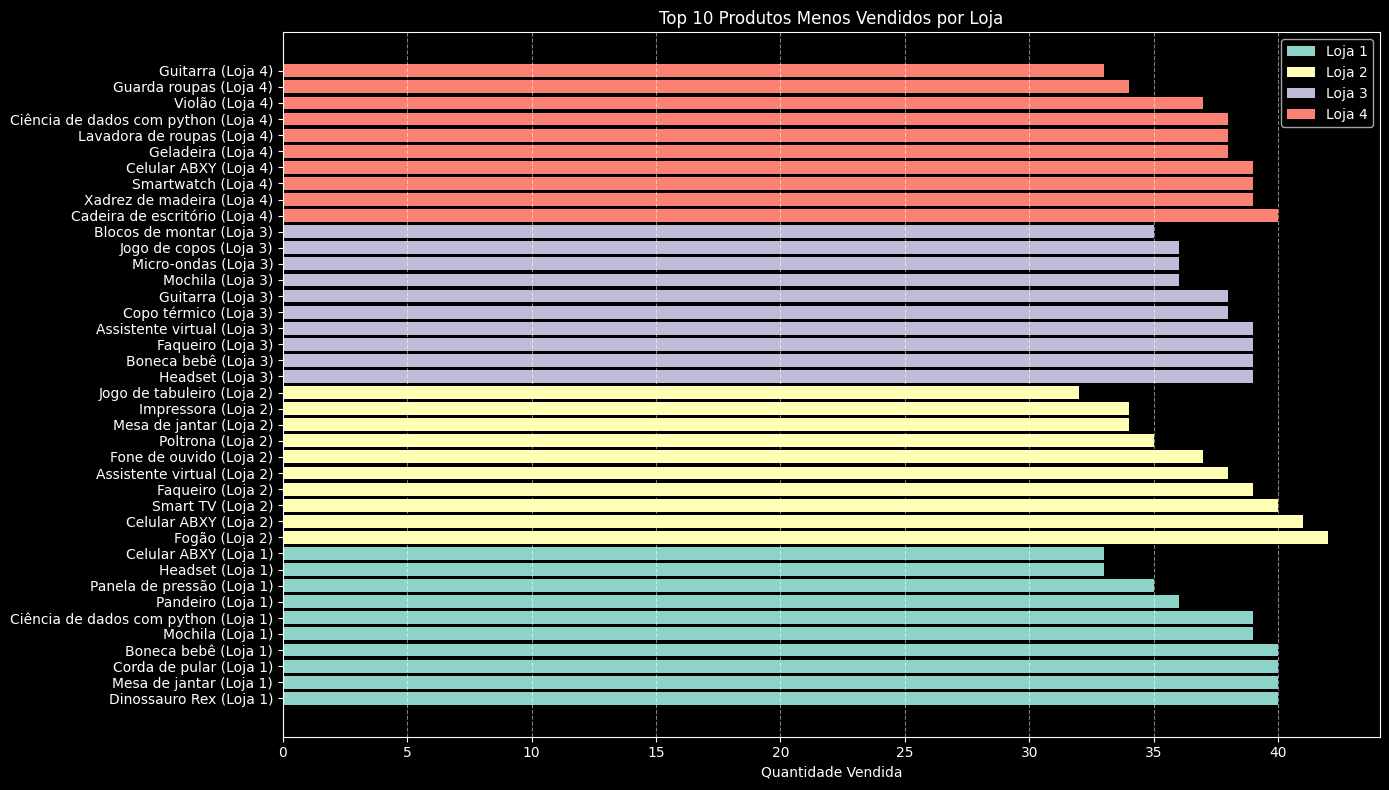

In [8]:

# Listando os produtos, realizando a contagem e obtendo os 10 menos vendidos.
print(f'\nMenos vendido na {Lojas[0]}:\n', loja["Produto"].value_counts().tail(10), '\n')
print(f'\nMenos vendido na {Lojas[1]}:\n', loja2["Produto"].value_counts().tail(10), '\n')
print(f'\nMenos vendido na {Lojas[2]}:\n', loja3["Produto"].value_counts().tail(10), '\n')
print(f'\nMenos vendido na {Lojas[3]}:\n', loja4["Produto"].value_counts().tail(10), '\n')

# Dados fornecidos
l1 = {
    'Produto': ['Dinossauro Rex', 'Mesa de jantar', 'Corda de pular', 'Boneca bebê', 'Mochila',
                'Ciência de dados com python', 'Pandeiro', 'Panela de pressão', 'Headset', 'Celular ABXY'],
    'Contagem': [40, 40, 40, 40, 39, 39, 36, 35, 33, 33]
}

l2 = {
    'Produto': ['Fogão', 'Celular ABXY', 'Smart TV', 'Faqueiro', 'Assistente virtual',
                'Fone de ouvido', 'Poltrona', 'Mesa de jantar', 'Impressora', 'Jogo de tabuleiro'],
    'Contagem': [42, 41, 40, 39, 38, 37, 35, 34, 34, 32]
}

l3 = {
    'Produto': ['Headset', 'Boneca bebê', 'Faqueiro', 'Assistente virtual', 'Copo térmico',
                'Guitarra', 'Mochila', 'Micro-ondas', 'Jogo de copos', 'Blocos de montar'],
    'Contagem': [39, 39, 39, 39, 38, 38, 36, 36, 36, 35]
}

l4 = {
    'Produto': ['Cadeira de escritório', 'Xadrez de madeira', 'Smartwatch', 'Celular ABXY', 'Geladeira',
                'Lavadora de roupas', 'Ciência de dados com python', 'Violão', 'Guarda roupas', 'Guitarra'],
    'Contagem': [40, 39, 39, 39, 38, 38, 38, 37, 34, 33]
}

# Criando DataFrames
df1 = pd.DataFrame(l1)
df2 = pd.DataFrame(l2)
df3 = pd.DataFrame(l3)
df4 = pd.DataFrame(l4)

# Adicionando a coluna da loja
df1['Loja'] = 'Loja 1'
df2['Loja'] = 'Loja 2'
df3['Loja'] = 'Loja 3'
df4['Loja'] = 'Loja 4'

# Combinando os DataFrames
df_total = pd.concat([df1, df2, df3, df4])

# Criando gráfico
plt.figure(figsize=(14, 8))
for nome_loja in df_total['Loja'].unique():
    df_loja = df_total[df_total['Loja'] == nome_loja]
    plt.barh(df_loja['Produto'] + f' ({nome_loja})', df_loja['Contagem'], label=nome_loja)

plt.xlabel('Quantidade Vendida')
plt.title('Top 10 Produtos Menos Vendidos por Loja')
plt.tight_layout()
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()



# 5. Frete Médio por Loja


In [15]:
#Usando a lista com o nome das lojas pra reduzir o código.
print(f'{Lojas[0]}:', locale.currency(loja['Frete'].mean(), grouping=True))
print(f'{Lojas[1]}:', locale.currency(loja2['Frete'].mean(), grouping=True))
print(f'{Lojas[2]}:', locale.currency(loja3['Frete'].mean(), grouping=True))
print(f'{Lojas[3]}:', locale.currency(loja4['Frete'].mean(), grouping=True))


1ª Loja: R$ 34,69
2ª Loja: R$ 33,62
3ª Loja: R$ 33,07
4ª Loja: R$ 31,28


#Relatório

Com base nos dados e gráficos, é perceptível que as quatro lojas são muito similares, e que a maioria das vendas ocorreu na primeira loja. No entanto, o frete de 34,69 é o mais alto, e sua avaliação é a pior entre todas, com uma média de 3,98.
Ao comparar com a quarta loja, percebe-se que ela apresenta um faturamento menor mais precisamente 150.011,54 a menos em relação à primeira loja, mas o frete é mais barato: 31,28 mais em conta em comparação com as demais. Vale ressaltar que a avaliação média dessa loja está acima da primeira, porém abaixo da segunda e da terceira.
Minha conclusão é que, caso a intenção seja vender, a quarta loja é a mais conveniente para essa ação, considerando o foco nas vendas. Caso o foco seja outro, será necessário sentar e analisar mais informações.

